# Project 1 — Pricing Baseline

**The Price of Fairness: Constrained Risk Pricing**

Now we build the pricing engine the whole project rests on:

* **Frequency model** — Poisson GLM (log link) for claim counts, with log(exposure) as an offset.
* **Severity model** — Gamma GLM (log link) for severity *per claim*.
* **Pure premium** = predicted frequency × predicted severity per claim.

We then check calibration two ways: how modeled premiums line up with empirical premiums by segment, and how they perform on a holdout set. This baseline is the "unfair" starting point — the thing constrained pricing will later trade away accuracy against fairness.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

import sys as _sys
_sys.path.insert(0, str(ROOT))

from src.load import load_claims
from src.models import (
    fit_frequency_model,
    fit_severity_model,
    predict_pure_premium,
    pure_premium_table,
)

plt.rcParams["figure.dpi"] = 110

df = load_claims(ROOT / "data" / "sample_claims.csv")
print(f"Loaded {len(df):,} policies")
df.head()

Loaded 10,000 policies


,policy_id,age,gender,territory,vehicle_type,annual_miles,driving_experience_years,exposure,claim_count,total_claim_amount
0,P0000001,23,F,A,truck,29209,5.9,0.6457,0,0.0
1,P0000002,66,M,A,truck,9272,50.7,0.5604,0,0.0
2,P0000003,59,M,A,truck,14440,41.1,0.5537,0,0.0
3,P0000004,45,F,C,sedan,9511,27.7,0.5047,0,0.0
4,P0000005,45,F,B,suv,18774,28.4,0.9892,0,0.0


## Train / test split

A simple 80/20 split keeps the holdout honest without leaking information into the models.

In [2]:
rng = np.random.default_rng(42)
df["fold"] = rng.choice(["train", "test"], size=len(df), p=[0.8, 0.2])
train = df[df["fold"] == "train"].copy()
test = df[df["fold"] == "test"].copy()
print(f"train: {len(train):,} | test: {len(test):,}")

train: 8,046 | test: 1,954


## Frequency model (Poisson GLM)

Claim counts are modeled with a log link and a log-exposure offset, so the fitted values are annual claim rates per policy-year.

In [3]:
freq_model = fit_frequency_model(train)
print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                 8046
Model:                            GLM   Df Residuals:                     8039
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3196.2
Date:                Sat, 08 Aug 2026   Deviance:                       4400.0
Time:                        14:54:09   Pearson chi2:                 8.23e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01017
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [4]:
effects = pd.DataFrame({
    "coef": freq_model.params,
    "exp(coef)": np.exp(freq_model.params),
    "p-value": freq_model.pvalues,
}).round(4)
effects

,coef,exp(coef),p-value
Intercept,-2.3138,0.0989,0.0000
C(gender)[T.M],0.2178,1.2433,0.0004
C(territory)[T.B],0.2422,1.2740,0.0017
C(territory)[T.C],0.5924,1.8083,0.0000
age,-0.0017,0.9983,0.9127
annual_miles,0.0000,1.0000,0.0054
driving_experience_years,0.0024,1.0024,0.8756


## Severity model (Gamma GLM)

Severity per claim (total loss ÷ claim count) is modeled with a Gamma family and log link — the standard actuarial choice for right-skewed loss amounts.

In [5]:
sev_model = fit_severity_model(train)
print(sev_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     severity_per_claim   No. Observations:                  971
Model:                            GLM   Df Residuals:                      965
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                         0.49771
Method:                          IRLS   Log-Likelihood:                -8734.4
Date:                Sat, 08 Aug 2026   Deviance:                       518.81
Time:                        14:54:09   Pearson chi2:                     480.
No. Iterations:                    11   Pseudo R-squ. (CS):             0.2709
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [6]:
effects = pd.DataFrame({
    "coef": sev_model.params,
    "exp(coef)": np.exp(sev_model.params),
    "p-value": sev_model.pvalues,
}).round(4)
effects

,coef,exp(coef),p-value
Intercept,7.0430,1144.7723,0.0000
C(territory)[T.B],0.0986,1.1036,0.0792
C(territory)[T.C],0.3791,1.4609,0.0000
C(vehicle_type)[T.suv],0.1704,1.1858,0.0013
C(vehicle_type)[T.truck],0.1979,1.2188,0.0009
age,0.0168,1.0170,0.0000


## Pure premium by segment

The table compares the empirical average loss per policy with the modeled pure premium (`frequency × severity per claim`) for each gender × territory segment. The `predicted/empirical` column is the calibration check.

In [7]:
pure_premium_table(train, freq_model, sev_model)

n_policies  empirical_premium  predicted_premium  \
gender territory                                                     
F      A                1650             263.45             269.69   
       B                1464             370.63             379.60   
       C                1061             736.67             718.02   
M      A                1542             342.66             338.08   
       B                1322             492.25             467.62   
       C                1007             901.03             895.97   

                  predicted/empirical  
gender territory                       
F      A                         1.02  
       B                         1.02  
       C                         0.97  
M      A                         0.99  
       B                         0.95  
       C                         0.99

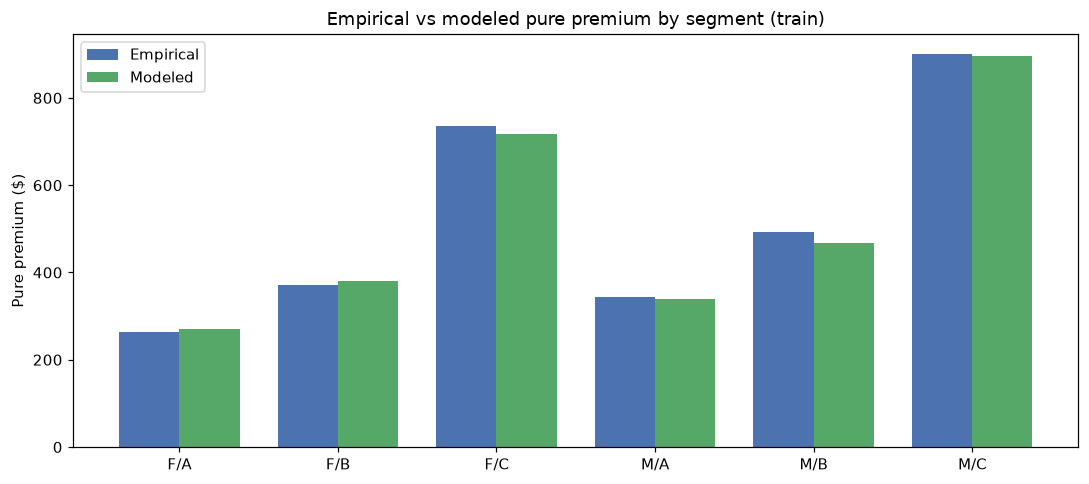

In [8]:
tab = pure_premium_table(train, freq_model, sev_model).reset_index()
tab["segment"] = tab["gender"] + "/" + tab["territory"]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tab))
width = 0.38
ax.bar(x - width / 2, tab["empirical_premium"], width, label="Empirical", color="#4C72B0")
ax.bar(x + width / 2, tab["predicted_premium"], width, label="Modeled", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(tab["segment"])
ax.set_ylabel("Pure premium ($)")
ax.set_title("Empirical vs modeled pure premium by segment (train)")
ax.legend()
plt.tight_layout()
plt.show()

## Holdout validation

Does the baseline price unseen policies correctly? We compare total predicted losses against total actual losses, then repeat the segment-level calibration on the test set.

In [9]:
test_pred = predict_pure_premium(freq_model, sev_model, test)
actual = test["total_claim_amount"]
print(f"Holdout total predicted:  ${test_pred.sum():,.0f}")
print(f"Holdout total actual:     ${actual.sum():,.0f}")
print(f"Holdout loss ratio (actual/predicted): {actual.sum() / test_pred.sum():.4f}")

Holdout total predicted:  $936,077
Holdout total actual:     $1,004,461
Holdout loss ratio (actual/predicted): 1.0731


In [10]:
hold = test.copy()
hold["predicted_premium"] = test_pred
by_seg = hold.groupby(["gender", "territory"], observed=True)[
    ["total_claim_amount", "predicted_premium"]
].mean()
by_seg["predicted/empirical"] = by_seg["predicted_premium"] / by_seg["total_claim_amount"]
by_seg.round(2)

total_claim_amount  predicted_premium  predicted/empirical
gender territory                                                            
F      A                      258.64             273.68                 1.06
       B                      386.42             383.71                 0.99
       C                      787.37             744.93                 0.95
M      A                      359.39             335.11                 0.93
       B                      636.91             478.01                 0.75
       C                      869.09             883.04                 1.02

## Observations

* **Frequency** — territory C is the biggest driver, followed by gender (M > F); the model is well calibrated overall (mean predicted count equals the empirical rate by construction of the Poisson GLM).
* **Severity** — older drivers, territory C, and trucks/SUVs cost more per claim, consistent with the data generator's design.
* **Calibration** — in-sample segment ratios sit near 1 (0.93–1.03); the holdout loss ratio is close to 1, so the baseline prices unseen policies accurately on average.
* **Fairness preview** — the baseline pure premium differs by roughly 2× between the cheapest segment (F/A) and the most expensive (M/C). That spread is exactly what constrained pricing will later compress — at a measurable cost to accuracy.